In [1]:
# Basic libraries
import os
import time
import warnings
import multiprocessing

# Data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Image processing
from pathlib import Path
from PIL import Image

# Feature extraction
from skimage.feature import hog, local_binary_pattern
from skimage.color import rgb2gray, rgb2hsv

# Machine learning
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy.stats import entropy
# Save model
import joblib

In [2]:
# Configuration Settings

# Dataset paths
IMAGE_ROOT = "Food_Image"   # Folder containing food images
NUTRITION_CSV = "food_nutrition_complete (1).csv"  # Nutrition dataset

# Image processing
IMG_SIZE = 64               # Resize images to 64x64
MAX_PER_CLASS = 100         # Limit images per class

# Model settings
RANDOM_STATE = 42

# Filtering parameters
CONFIDENCE_MIN = 0.20       # Minimum confidence threshold
ENTROPY_MAX = 0.80          # Maximum entropy (for filtering noisy data)

# Feature caching (to speed up future runs)
FEATURE_CACHE = "features_cache.npz"   # Set None to disable

In [3]:
# =========================
# Feature Extraction
# =========================

def extract_features(img):
    """
    Extract features from image (64x64 RGB)

    Features:
    - HOG (shape)
    - LBP (texture)
    - HSV histogram (color)
    - Color moments
    """

    # Convert to grayscale
    gray = rgb2gray(img)

    # -------- HOG (fine) --------
    hog_fine = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    # -------- HOG (coarse) --------
    hog_coarse = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    # -------- LBP (FIXED) --------
    # Convert to uint8 to avoid warning
    gray_uint8 = (gray * 255).astype(np.uint8)

    lbp = local_binary_pattern(gray_uint8, 24, 3, method='uniform')

    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=26,
        range=(0, 26),
        density=True
    )

    # -------- HSV histogram --------
    hsv = rgb2hsv(img)
    hsv_features = []

    for i in range(3):
        hist, _ = np.histogram(hsv[:, :, i], bins=32, range=(0, 1))
        hist = hist / (hist.sum() + 1e-9)
        hsv_features.extend(hist)

    # -------- Color moments --------
    moments = []

    for i in range(3):
        channel = img[:, :, i].ravel()
        mean = np.mean(channel)
        std = np.std(channel)
        skew = np.mean((channel - mean) ** 3)

        moments.extend([mean, std, skew])

    # -------- Combine features --------
    features = np.concatenate([
        hog_fine,
        hog_coarse,
        lbp_hist,
        hsv_features,
        moments
    ])

    return features.astype(np.float32)

In [4]:
# =========================
# Speed Test
# =========================

test_img = np.random.rand(64, 64, 3).astype(np.float32)

times = []

for i in range(20):
    start = time.time()
    extract_features(test_img)
    times.append(time.time() - start)

avg_time = np.mean(times) * 1000

print("Feature size :", len(extract_features(test_img)))
print("Time per image :", round(avg_time, 2), "ms")

Feature size : 2219
Time per image : 11.7 ms


In [5]:
# Parallel Image Loading

def load_single_image(args):
    """Load one image and extract features."""
    path, label, size = args

    try:
        img = Image.open(path).convert("RGB")
        img = img.resize((size, size))

        img = np.array(img, dtype=np.float32) / 255.0

        features = extract_features(img)

        return features, label

    except:
        return None


def load_dataset(root_path, img_size, max_per_class, seed=42, cache_path=None):

    root = Path(root_path)

    # ---------- Load from cache ----------
    if cache_path and Path(cache_path).exists():
        print("Loading from cache...")
        data = np.load(cache_path, allow_pickle=True)

        X = data["X"]
        y = list(data["y"])

        print("Loaded", len(X), "images")
        return X, y

    # ---------- Collect image paths ----------
    classes = [d for d in root.iterdir() if d.is_dir()]

    if len(classes) == 0:
        print("No class folders found!")
        return np.array([]), []

    np.random.seed(seed)

    tasks = []

    for cls in classes:
        images = list(cls.glob("*.jpg")) + list(cls.glob("*.png"))

        np.random.shuffle(images)

        for img_path in images[:max_per_class]:
            tasks.append((img_path, cls.name, img_size))

    print("Total classes :", len(classes))
    print("Total images  :", len(tasks))
    print("Using cores   :", N_CORES)

    # ---------- Parallel processing ----------
    start = time.time()

    with ThreadPoolExecutor(max_workers=N_CORES) as executor:
        results = list(executor.map(load_single_image, tasks))

    # Remove failed images
    results = [r for r in results if r is not None]

    X = np.array([r[0] for r in results], dtype=np.float32)
    y = [r[1] for r in results]

    print("Loaded", len(X), "images in", round(time.time() - start, 2), "sec")

    # ---------- Save cache ----------
    if cache_path:
        np.savez_compressed(cache_path, X=X, y=np.array(y))
        print("Cache saved:", cache_path)

    return X, y

In [6]:
X_raw, labels = load_dataset(
    IMAGE_ROOT,
    IMG_SIZE,
    MAX_PER_CLASS,
    cache_path=FEATURE_CACHE
)

Loading from cache...
Loaded 9577 images


In [7]:
# Cache Management

# -------- Check cache info --------
if FEATURE_CACHE and Path(FEATURE_CACHE).exists():

    cache = np.load(FEATURE_CACHE, allow_pickle=True)

    size_mb = Path(FEATURE_CACHE).stat().st_size / 1024 / 1024

    print("Cache file     :", FEATURE_CACHE)
    print("Cache size     :", round(size_mb, 2), "MB")
    print("Total images   :", len(cache["X"]))
    print("Total classes  :", len(set(cache["y"])))

else:
    print("Cache not found. Run dataset loading to create it.")

Cache file     : features_cache.npz
Cache size     : 63.14 MB
Total images   : 9577
Total classes  : 203


In [8]:
# Train-Test Split

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(labels)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_raw,
    y_encoded,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_encoded
)

# Print info
print("Number of classes :", len(le.classes_))
print("Training samples  :", len(X_train))
print("Testing samples   :", len(X_test))

Number of classes : 203
Training samples  : 7661
Testing samples   : 1916


In [9]:
# Scale + Train Model

# Scale features
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Neural Network model
model = MLPClassifier(
    hidden_layer_sizes=(128, 64),   # simple and effective
    activation='relu',
    max_iter=300,
    random_state=RANDOM_STATE
)

# Train model
start = time.time()

model.fit(X_train_scaled, y_train)

end = time.time()

print("Training completed in", round(end - start, 2), "seconds")
print("Epochs used:", model.n_iter_)

Training completed in 102.41 seconds
Epochs used: 110


In [10]:
# =========================
# Model Evaluation
# =========================

from sklearn.metrics import accuracy_score, classification_report

# Predict
y_pred = model.predict(X_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy :", round(accuracy * 100, 2), "%")

# Detailed report
print("\nClassification Report:\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_,
    zero_division=0
))

Test Accuracy : 10.75 %

Classification Report:

                              precision    recall  f1-score   support

                     Abalone       0.00      0.00      0.00         2
                    Ambrosia       1.00      0.33      0.50         3
                   Artichoke       0.00      0.00      0.00         2
                       Atole       1.00      0.50      0.67         2
                       Bagel       0.00      0.00      0.00         2
                     Baklava       0.00      0.00      0.00        10
                      Barley       0.00      0.00      0.00         1
                    Basbousa       0.00      0.00      0.00         2
                        Beer       0.00      0.00      0.00         3
                       Bread       0.00      0.00      0.00        10
                     Brioche       0.00      0.00      0.00         2
                  Bruschetta       0.00      0.00      0.00        10
                  Buttermilk       0.00 

In [11]:
# Save Model Files

# Save model and related objects
joblib.dump(model, "food_model.pkl")
joblib.dump(scaler, "food_scaler.pkl")
joblib.dump(le, "label_encoder.pkl")

print("Model and files saved successfully")

Model and files saved successfully


In [12]:


# =========================
# Load Nutrition Data
# =========================

nutrition_df = pd.read_csv(NUTRITION_CSV)

# Clean food names
nutrition_df["food_name"] = (
    nutrition_df["food_name"]
    .str.lower()
    .str.strip()
    .str.replace("_", " ")
    .str.replace("-", " ")
)

# Remove duplicates
nutrition_df = nutrition_df.drop_duplicates("food_name")

# Convert to dictionary
nutrition_dict = nutrition_df.set_index("food_name").to_dict(orient="index")

#print("Nutrition entries:", len(nutrition_dict))


# =========================
# Get Nutrition Function
# =========================

def get_nutrition(food_label):

    key = food_label.lower().replace("_", " ").strip()

    # Exact match
    if key in nutrition_dict:
        return nutrition_dict[key]

    # Partial match
    for name in nutrition_dict:
        if key in name or name in key:
            return nutrition_dict[name]

    return None


# =========================
# Unknown Detection
# =========================

def check_unknown(proba):

    max_prob = np.max(proba)

    entropy_val = entropy(proba + 1e-10)
    norm_entropy = entropy_val / np.log(len(proba))

    if max_prob < CONFIDENCE_MIN or norm_entropy > ENTROPY_MAX:
        return True, max_prob * 100

    return False, max_prob * 100


# =========================
# Prediction Function
# =========================

def predict_food(image_path):

    try:
        img = Image.open(image_path).convert("RGB")
    except Exception as e:
        print("Error loading image:", e)
        return

    # Resize + normalize
    img_resized = img.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img_resized, dtype=np.float32) / 255.0

    # Extract features
    features = extract_features(img_array).reshape(1, -1)

    # Scale features
    features = scaler.transform(features)

    # Predict probabilities
    proba = model.predict_proba(features)[0]

    # Get predicted label
    top_index = np.argmax(proba)
    label = le.inverse_transform([top_index])[0]

    # Check confidence
    is_unk, confidence = check_unknown(proba)

    # Get nutrition
    nutrition = get_nutrition(label)

    # -------- Output --------
    print("\nPrediction Result")
    print("------------------")
    print("Food       :", label.replace("_", " ").title())
    print("Confidence :", round(confidence, 2), "%")

    if is_unk:
        print("Status     : Low confidence / Unknown")

    if nutrition:
        print("\nNutrition (per 100g):")
        print("Calories :", nutrition.get("calories_kcal", "N/A"))
        print("Protein  :", nutrition.get("protein_g", "N/A"))
        print("Fat      :", nutrition.get("fat_g", "N/A"))
        print("Carbs    :", nutrition.get("carbohydrates_g", "N/A"))

    # Show image
    plt.imshow(img)
    plt.axis("off")
    plt.title(label.replace("_", " ").title())
    plt.show()

Testing image...

Prediction Result
------------------
Food       : Pizza
Confidence : 93.67 %

Nutrition (per 100g):
Calories : 278.0
Protein  : 12.5
Fat      : 10.8
Carbs    : 32.5


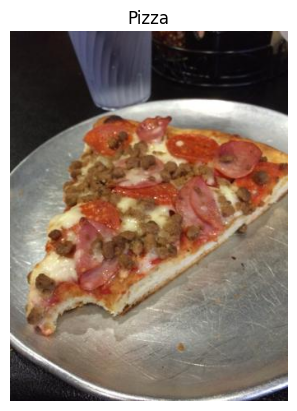

In [15]:
# Test with Single Image

TEST_IMAGE = r"D:\BDA_SEM_2_RESE\final_research_project\TEST_IMAGE\the-pizza-is-bigger-in.jpg"
# Check if file exists
if os.path.exists(TEST_IMAGE):
    print("Testing image...")
    predict_food(TEST_IMAGE)
else:
    print("Image not found!")
    print("Please check the path:", TEST_IMAGE)